In [1]:
import os
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
import numpy as np

# Instala as bibliotecas se estiver no Colab (descomente a linha abaixo se precisar)
# !pip install geopandas shapely

# Cria a pasta dados
os.makedirs('dados', exist_ok=True)

# Limites geográficos aproximados de Minas Gerais
lon_min, lon_max = -51.0, -39.0
lat_min, lat_max = -22.0, -14.0

def gerar_mock_desmatamento(nome_arquivo, qtd_focos):
    print(f"Gerando dados simulados para {nome_arquivo}...")

    # Gera coordenadas aleatórias dentro de MG
    lons = np.random.uniform(lon_min, lon_max, qtd_focos)
    lats = np.random.uniform(lat_min, lat_max, qtd_focos)

    # Cria polígonos (buffer em volta do ponto simula a área desmatada)
    # O tamanho do buffer varia aleatoriamente
    geometrias = [Point(lon, lat).buffer(np.random.uniform(0.01, 0.05)) for lon, lat in zip(lons, lats)]

    # Sorteia os biomas de MG
    biomas = np.random.choice(['Cerrado', 'Mata Atlântica', 'Caatinga'], qtd_focos, p=[0.55, 0.40, 0.05])

    # Cria o GeoDataFrame (em WGS84 - EPSG:4326, que é o padrão de GPS)
    gdf = gpd.GeoDataFrame({'bioma': biomas}, geometry=geometrias, crs="EPSG:4326")

    # Salva como GeoPackage (.gpkg)
    gdf.to_file(f'dados/{nome_arquivo}', driver="GPKG")
    print(f"✅ {nome_arquivo} criado com sucesso!")

# Gera 150 focos para agosto e 200 para setembro
gerar_mock_desmatamento('desmatamento_ago22.gpkg', 150)
gerar_mock_desmatamento('desmatamento_set_22.gpkg', 200)

Gerando dados simulados para desmatamento_ago22.gpkg...
✅ desmatamento_ago22.gpkg criado com sucesso!
Gerando dados simulados para desmatamento_set_22.gpkg...
✅ desmatamento_set_22.gpkg criado com sucesso!


In [1]:
!pip install geopandas geobr folium matplotlib seaborn

In [5]:
import pandas as pd
import numpy as np
import geopandas as gpd
from geobr import read_municipality
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('dados', exist_ok=True)

print("Baixando dados dos municípios de MG...")
mg = read_municipality(code_muni="MG", year=2020)
mg = mg.to_crs(epsg=31983)
mg['area_km2'] = mg.geometry.area / (10**6)
mg.to_file('dados/municipios-mg.geojson', driver='GeoJSON')
print("✅ 'municipios-mg.geojson' salvo!")

print("Gerando dados socioeconômicos simulados...")
nomes_muni = mg['name_muni'].unique()
df_ibge = pd.DataFrame({
    'municipio': nomes_muni,
    'populacao_2022': np.random.randint(5000, 2500000, len(nomes_muni)),
    'pib_mil_reais': np.random.randint(10000, 90000000, len(nomes_muni))
})
df_ibge.to_csv('dados/populacao-pib-municipios-mg.csv', index=False)
print("✅ 'populacao-pib-municipios-mg.csv' salvo!")

print("Unificando focos de desmatamento...")
# Aqui ele pega os arquivos que você gerou na Célula 2
ago = gpd.read_file('dados/desmatamento_ago22.gpkg')
setem = gpd.read_file('dados/desmatamento_set_22.gpkg')
ago['mes'] = 'Agosto'
setem['mes'] = 'Setembro'

focos = pd.concat([ago, setem], ignore_index=True)
focos = gpd.GeoDataFrame(focos, geometry='geometry', crs="EPSG:4326")
focos = focos.to_crs(epsg=31983)
focos.to_file('dados/focos-desmatamento-mg.geojson', driver='GeoJSON')
print("✅ 'focos-desmatamento-mg.geojson' salvo com sucesso!")

Baixando dados dos municípios de MG...
✅ 'municipios-mg.geojson' salvo!
Gerando dados socioeconômicos simulados...
✅ 'populacao-pib-municipios-mg.csv' salvo!
Unificando focos de desmatamento...
✅ 'focos-desmatamento-mg.geojson' salvo com sucesso!


In [6]:
import geopandas as gpd
import pandas as pd
from IPython.display import display

# Carregar os dados que foram gerados na Célula 3
municipios = gpd.read_file('dados/municipios-mg.geojson')
focos = gpd.read_file('dados/focos-desmatamento-mg.geojson')
socioeco = pd.read_csv('dados/populacao-pib-municipios-mg.csv')

# Calcular áreas
focos['area_desmatada_ha'] = focos.geometry.area / 10000
focos['area_desmatada_km2'] = focos.geometry.area / 10**6

# Cruzamento Espacial (quais focos caem em quais municípios)
focos_muni = gpd.sjoin(focos, municipios, how="inner", predicate="intersects")

print("--- 1. Área total desmatada por mês (Hectares) ---")
area_mes_ha = focos.groupby('mes')['area_desmatada_ha'].sum().reset_index()
display(area_mes_ha)

print("\n--- 2. Área total desmatada por Bioma (km²) ---")
area_bioma_km2 = focos.groupby('bioma')['area_desmatada_km2'].sum().reset_index()
display(area_bioma_km2)

print("\n--- 3. Área total desmatada por Município e Mês (km²) [Top 10] ---")
area_muni_mes_km2 = focos_muni.groupby(['name_muni', 'mes'])['area_desmatada_km2'].sum().reset_index()
display(area_muni_mes_km2.sort_values(by='area_desmatada_km2', ascending=False).head(10))

--- 1. Área total desmatada por mês (Hectares) ---


,mes,area_desmatada_ha
0,Agosto,573957.403827
1,Setembro,781393.055719



--- 2. Área total desmatada por Bioma (km²) ---


,bioma,area_desmatada_km2
0,Caatinga,562.110675
1,Cerrado,7785.403344
2,Mata Atlântica,5205.990576



--- 3. Área total desmatada por Município e Mês (km²) [Top 10] ---


,name_muni,mes,area_desmatada_km2
154,Minas Novas,Agosto,229.565386
89,Frei Gaspar,Setembro,140.510880
114,Itacarambi,Setembro,135.409296
203,Prata,Agosto,122.335972
13,Arinos,Agosto,117.243794
65,Coronel Murta,Setembro,116.185099
29,Brasilândia De Minas,Setembro,112.813423
68,Curvelo,Setembro,106.717145
16,Açucena,Setembro,90.164018
116,Itamarandiba,Setembro,90.157041


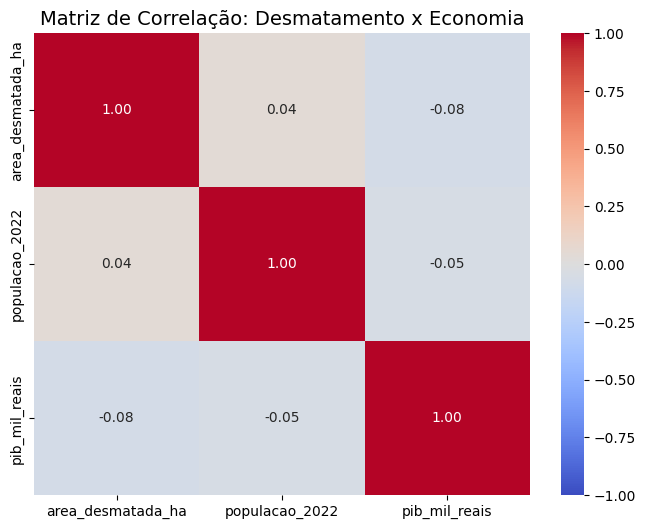

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Agregar desmatamento total (ha) por município
desmatamento_total_muni = focos_muni.groupby('name_muni')['area_desmatada_ha'].sum().reset_index()

# Mesclar com PIB e População
df_correlacao = pd.merge(desmatamento_total_muni, socioeco, left_on='name_muni', right_on='municipio', how='inner')

# Calcular correlação
correlacao = df_correlacao[['area_desmatada_ha', 'populacao_2022', 'pib_mil_reais']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matriz de Correlação: Desmatamento x Economia', fontsize=14)
plt.show()

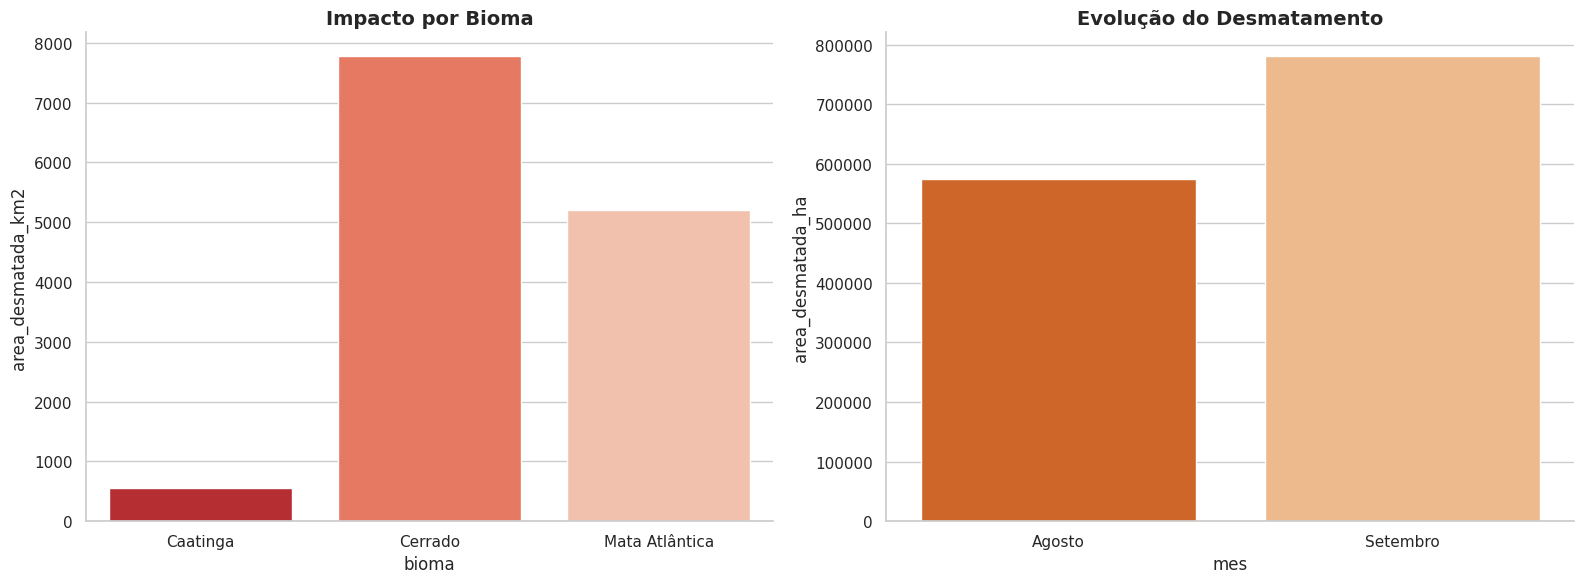

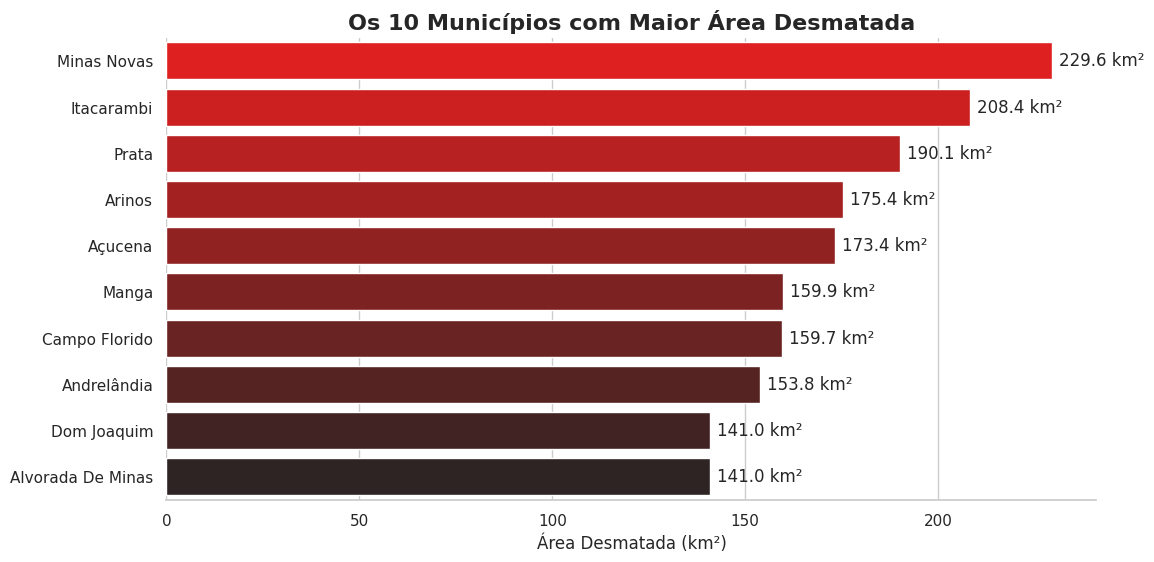

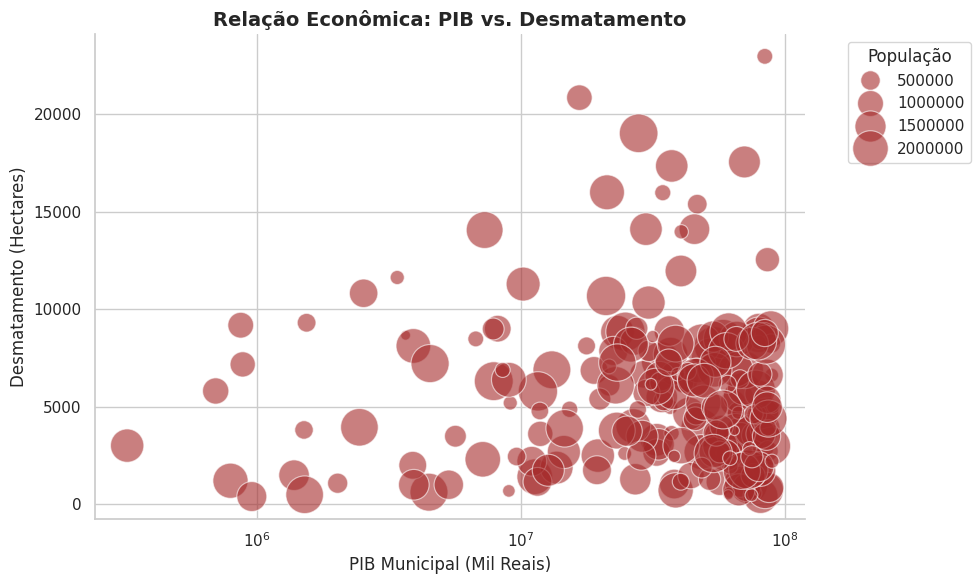

In [8]:
import folium

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'

# VISUALIZAÇÕES 1 E 2: Biomas e Tempo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=area_bioma_km2, x='bioma', y='area_desmatada_km2', ax=axes[0], palette='Reds_r')
axes[0].set_title('Impacto por Bioma', fontsize=14, fontweight='bold')

sns.barplot(data=area_mes_ha, x='mes', y='area_desmatada_ha', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Evolução do Desmatamento', fontsize=14, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

# VISUALIZAÇÃO 3: Top 10 Municípios
top10_muni = area_muni_mes_km2.groupby('name_muni')['area_desmatada_km2'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top10_muni, y='name_muni', x='area_desmatada_km2', palette='dark:red_r')
plt.title('Os 10 Municípios com Maior Área Desmatada', fontsize=16, fontweight='bold')
plt.xlabel('Área Desmatada (km²)')
plt.ylabel('')
for i in ax.containers: ax.bar_label(i, padding=5, fmt='%.1f km²')
sns.despine(left=True)
plt.show()

# VISUALIZAÇÃO 4: Relação Econômica
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_correlacao, x='pib_mil_reais', y='area_desmatada_ha',
                size='populacao_2022', sizes=(50, 800), alpha=0.6, color='brown')
plt.title('Relação Econômica: PIB vs. Desmatamento', fontsize=14, fontweight='bold')
plt.xlabel('PIB Municipal (Mil Reais)')
plt.ylabel('Desmatamento (Hectares)')
plt.xscale('log')
plt.legend(title='População', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

# VISUALIZAÇÃO 5: Mapa Interativo
mapa_dados = focos_muni.groupby('name_muni')['area_desmatada_km2'].sum().reset_index()
mun_mapa = municipios.merge(mapa_dados, on='name_muni', how='left').fillna(0)
mun_mapa_wgs84 = mun_mapa.to_crs(epsg=4326)

m = folium.Map(location=[-18.5122, -44.5550], zoom_start=6, tiles='CartoDB positron')
folium.Choropleth(
    geo_data=mun_mapa_wgs84,
    name='Áreas Críticas',
    data=mun_mapa_wgs84,
    columns=['name_muni', 'area_desmatada_km2'],
    key_on='feature.properties.name_muni',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Área Desmatada (km²)',
).add_to(m)

m.save('dados/mapa_fiscalizacao.html')
display(m)